In [12]:
from IPython.display import Image, display, clear_output
import os
import random
import time

%cd /home/kobashi/open-eqa/
# データ読み込み
import json

vision_output_path = "data/results/human_vision.json"
blind_output_path = "data/results/human_blind.json"

def load_episode_histories():
    episode_histories = {}
    for row in json.load(open("data/open-eqa-v0_sceneType.json")):
        if "sceneType" in row:
            episode_history = row["episode_history"]
            if not episode_history in episode_histories:
                episode_histories[episode_history] = {"questions":[], "answers":[], "sceneType": row["sceneType"]}
            episode_histories[episode_history]["questions"].append(row["question"])
            episode_histories[episode_history]["answers"].append(row["answer"])
    return episode_histories

/home/kobashi/open-eqa


In [ ]:
# Q&Aだけで回答できるか判断
if os.path.exists(blind_output_path):
    episode_histories = json.load(open(blind_output_path))
else:
    episode_histories = load_episode_histories()
episode_history_list = [(episode_history, row) for episode_history, row in episode_histories.items() if not "difficulty" in row]
print("N:", len(episode_history_list))
random.shuffle(episode_history_list)

for episode_history,row in episode_history_list:
    if "difficulty" in row:
        continue
    print(["Apartment", "Bathroom", "Bedroom / Hotel", "Bookstore / Library", "Classroom", "Conference Room", "Copy / Mail Room", "Kitchen", "Laundry Room", "Living room / Lounge", "Lobby", "Office", "Storage / Basement / Garage"])
    for q, a in zip(row["questions"], row["answers"]):
        print("Q:", q)
        print("A:", a)
    print(["Apartment", "Bathroom", "Bedroom / Hotel", "Bookstore / Library", "Classroom", "Conference Room", "Copy / Mail Room", "Kitchen", "Laundry Room", "Living room / Lounge", "Lobby", "Office", "Storage / Basement / Garage"])
    time.sleep(0.2)
    your_answer = input("Please choose the category:").strip()
    print(f"the answer is {row["sceneType"]}")
    episode_histories[episode_history]["estimated_sceneType"] = your_answer
    time.sleep(0.2)
    difficulty = input("This is 1:include the answer, 2:can estimate by human, 3:impossible:").strip()
    episode_histories[episode_history]["difficulty"] = int(difficulty)
    json.dump(episode_histories, open(blind_output_path, "w"), indent=2)
    clear_output(True)

['Apartment', 'Bathroom', 'Bedroom / Hotel', 'Bookstore / Library', 'Classroom', 'Conference Room', 'Copy / Mail Room', 'Kitchen', 'Laundry Room', 'Living room / Lounge', 'Lobby', 'Office', 'Storage / Basement / Garage']
Q: What is the title of the book on the coffee table?
A: Sailing
Q: What is the brown elongated object on the rug?
A: poster tube
Q: What is the color of shoe rack?
A: cherry wood
Q: What is the background color of the framed photo near the entrance?
A: white
Q: If I am sitting on the couch and looking directly at the book shelf, where would the shoe rack be located relative to me? Answer from among front, behind, left, or right.
A: behind
Q: Is the bookshelf empty?
A: no
Q: Is this room tidy or cluttered?
A: cluttered 
Q: Who is depicted on the framed photo next to the wooden door?
A: Gandhi
Q: Where is the gray colored pillow?
A: on the floor, near the couch
Q: Where is the book on sailing located?
A: On the coffee table
['Apartment', 'Bathroom', 'Bedroom / Hotel', '

['Apartment', 'Bathroom', 'Bedroom / Hotel', 'Bookstore / Library', 'Classroom', 'Conference Room', 'Copy / Mail Room', 'Kitchen', 'Laundry Room', 'Living room / Lounge', 'Lobby', 'Office', 'Storage / Basement / Garage']


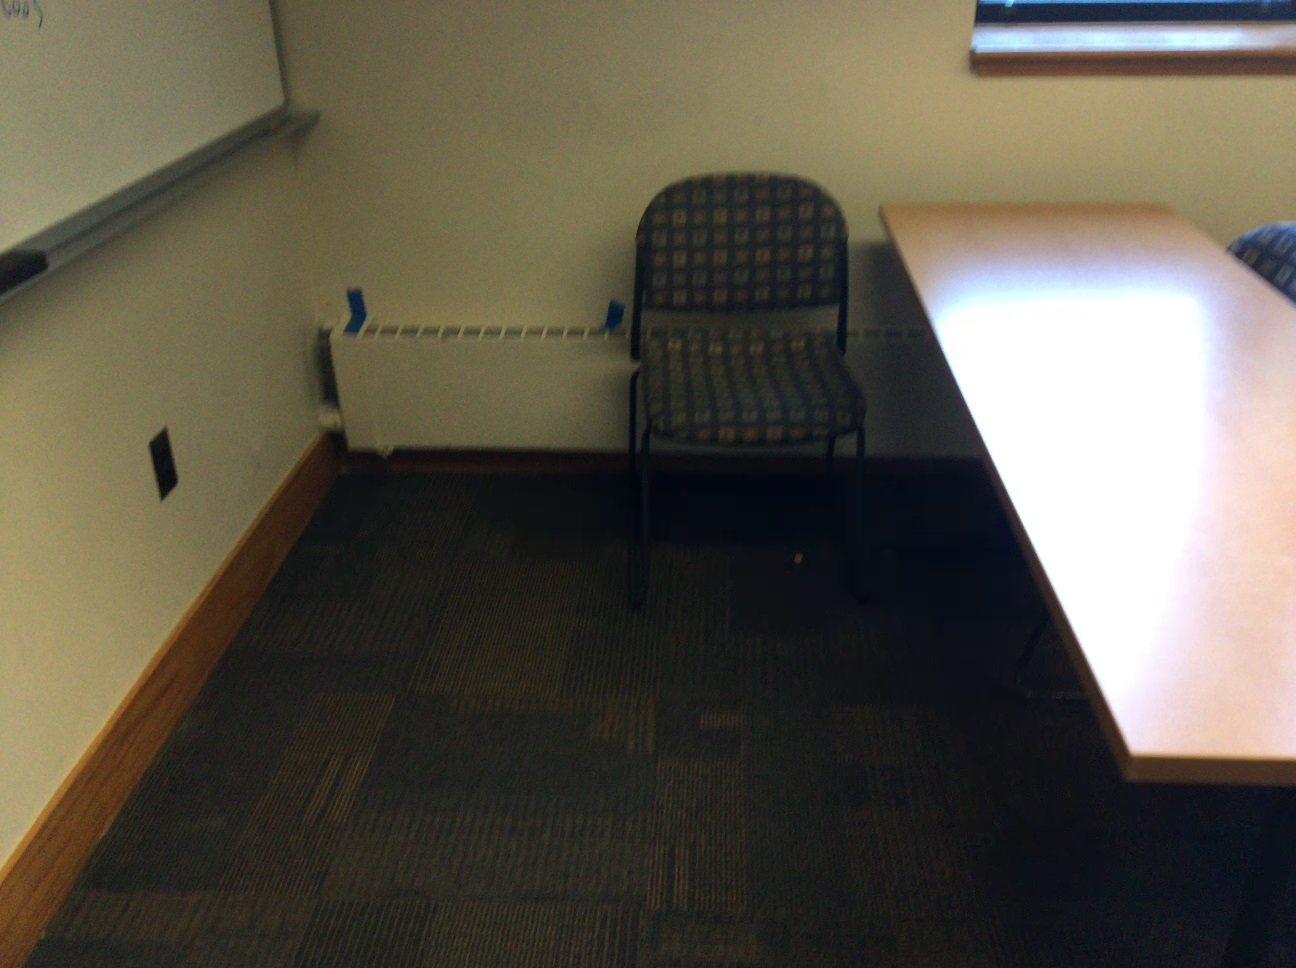

['Apartment', 'Bathroom', 'Bedroom / Hotel', 'Bookstore / Library', 'Classroom', 'Conference Room', 'Copy / Mail Room', 'Kitchen', 'Laundry Room', 'Living room / Lounge', 'Lobby', 'Office', 'Storage / Basement / Garage']
the answer is Classroom


In [ ]:
# 画像だけで回答できるか判断
if os.path.exists(vision_output_path):
    episode_histories = json.load(open(vision_output_path))
else:
    episode_histories = load_episode_histories()
episode_history_list = [(episode_history, row) for episode_history, row in episode_histories.items() if not "difficulty" in row]
print("N:", len(episode_history_list))
random.shuffle(episode_history_list)

for episode_history,row in episode_history_list:
    if "difficulty" in row:
        continue
    print(["Apartment", "Bathroom", "Bedroom / Hotel", "Bookstore / Library", "Classroom", "Conference Room", "Copy / Mail Room", "Kitchen", "Laundry Room", "Living room / Lounge", "Lobby", "Office", "Storage / Basement / Garage"])
    display(Image(f"data/scene_images/{episode_history}.png", width=400))
    print(["Apartment", "Bathroom", "Bedroom / Hotel", "Bookstore / Library", "Classroom", "Conference Room", "Copy / Mail Room", "Kitchen", "Laundry Room", "Living room / Lounge", "Lobby", "Office", "Storage / Basement / Garage"])
    your_answer = input("Please choose the category:").strip()
    print(f"the answer is {row["sceneType"]}")
    episode_histories[episode_history]["estimated_sceneType"] = your_answer
    time.sleep(0.2)
    difficulty = input("This is 1:include the answer, 2:can estimate by human, 3:impossible:").strip()
    episode_histories[episode_history]["difficulty"] = int(difficulty)
    json.dump(episode_histories, open(vision_output_path, "w"), indent=2)
    clear_output(True)

In [17]:
# データの整合性チェック
text_and_vision_data = {}
if os.path.exists(blind_output_path) and os.path.exists(vision_output_path):
    blind_estimated_data = json.load(open(blind_output_path))
    vision_estimated_data = json.load(open(vision_output_path))
    freq = {"text":{1:0, 2:0, 3:0}, "vision":{1:0, 2:0, 3:0}, "both":{1:0, 2:0, 3:0}}
    for episode_history, row in blind_estimated_data.items():
        freq["text"][row["difficulty"]] += 1
        freq["vision"][vision_estimated_data[episode_history]["difficulty"]] += 1
        freq["both"][min(row["difficulty"], vision_estimated_data[episode_history]["difficulty"])] += 1
        text_and_vision_data[episode_history] = {}
        text_and_vision_data[episode_history]["questions"] = row["questions"]
        text_and_vision_data[episode_history]["answers"] = row["answers"]
        text_and_vision_data[episode_history]["sceneType"] = row["sceneType"]
        text_and_vision_data[episode_history]["text_estimated_sceneType"] = row["estimated_sceneType"]
        text_and_vision_data[episode_history]["text_difficulty"] = row["difficulty"]
        text_and_vision_data[episode_history]["vision_estimated_sceneType"] = vision_estimated_data[episode_history]["estimated_sceneType"]
        text_and_vision_data[episode_history]["vision_difficulty"] = vision_estimated_data[episode_history]["difficulty"]
print(freq)

{'text': {1: 16, 2: 39, 3: 24}, 'vision': {1: 0, 2: 55, 3: 24}, 'both': {1: 16, 2: 49, 3: 14}}


In [ ]:
# テキストと画像で回答できるか判断
output_path = "data/results/human_text_and_vision.json"
if os.path.exists(output_path):
    episode_histories = json.load(open(output_path))
else:
    episode_histories = text_and_vision_data
episode_history_list = [(episode_history, row) for episode_history, row in episode_histories.items() if not "difficulty" in row]
print("N:", len(episode_history_list))
random.shuffle(episode_history_list)

for episode_history,row in episode_history_list:
    if "difficulty" in row:
        continue
    if row["sceneType"] == row["text_estimated_sceneType"] == row["vision_estimated_sceneType"]:
        episode_histories[episode_history]["estimated_sceneType"] = row["sceneType"]
        episode_histories[episode_history]["difficulty"] = min(row["text_difficulty"], row["vision_difficulty"])
        continue
    print(["Apartment", "Bathroom", "Bedroom / Hotel", "Bookstore / Library", "Classroom", "Conference Room", "Copy / Mail Room", "Kitchen", "Laundry Room", "Living room / Lounge", "Lobby", "Office", "Storage / Basement / Garage"])
    for q, a in zip(row["questions"], row["answers"]):
        print("Q:", q)
        print("A:", a)
    display(Image(f"data/scene_images/{episode_history}.png", width=400))
    print(["Apartment", "Bathroom", "Bedroom / Hotel", "Bookstore / Library", "Classroom", "Conference Room", "Copy / Mail Room", "Kitchen", "Laundry Room", "Living room / Lounge", "Lobby", "Office", "Storage / Basement / Garage"])
    time.sleep(0.2)
    your_answer = input("Please choose the category:").strip()
    print(f"the answer is {row["sceneType"]}")
    episode_histories[episode_history]["estimated_sceneType"] = your_answer
    time.sleep(0.2)
    difficulty = input("This is 1:include the answer, 2:can estimate by human, 3:impossible:").strip()
    episode_histories[episode_history]["difficulty"] = int(difficulty)
    json.dump(episode_histories, open(output_path, "w"), indent=2)
    clear_output(True)